# 07 — ML Final Results

Presentation-quality ML results. Feature importance, actual vs predicted, and residual analysis for the best model.
This notebook is used for the course presentation and final report.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from Source.scripts.helpers import PROCESSED_DATA_DIR

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130

# Load and prepare data
df = pd.read_csv(PROCESSED_DATA_DIR / 'movies_merged.csv')
FEATURES = ['budget', 'runtime', 'release_year', 'primary_genre', 'decade']
TARGET   = 'revenue'

ml_df      = df[FEATURES + [TARGET]].dropna()
ml_encoded = pd.get_dummies(ml_df, columns=['primary_genre', 'decade'], drop_first=True)

X = ml_encoded.drop(columns=[TARGET])
y = ml_encoded[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

print(f'Ready — train: {X_train.shape}, test: {X_test.shape}')

Ready — train: (4214, 32), test: (1054, 32)


## Problem Definition

> **Target:** A film's box office revenue
>
> **Problem type:** Regression (continuous numerical output)
>
> **Features used:** `budget`, `runtime`, `release_year`, `primary_genre`, `decade`
>
> **Models compared:** Linear Regression (baseline) vs Random Forest Regressor
>
> **Why these two models?**
> Linear Regression is the easiest to interpret and establishes a baseline.
> Random Forest captures non-linear relationships and produces feature importance scores,
> allowing us to understand which variable has the most impact on revenue.

## Cross-Validation Comparison

Test set results are measured on a single split. Cross-validation gives a more reliable estimate.

In [2]:
cv_lr = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring='r2')
cv_rf = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, y_train, cv=5, scoring='r2'
)

print(f'Linear Regression  CV R2: {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}')
print(f'Random Forest      CV R2: {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}')

Linear Regression  CV R2: 0.5471 +/- 0.0217
Random Forest      CV R2: 0.5356 +/- 0.0403


## Results Table

In [3]:
def metrics(name, y_true, y_pred):
    return {
        'Model'       : name,
        'MAE (M USD)' : round(mean_absolute_error(y_true, y_pred) / 1e6, 1),
        'RMSE (M USD)': round(root_mean_squared_error(y_true, y_pred) / 1e6, 1),
        'R2'          : round(r2_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    metrics('Linear Regression', y_test, y_pred_lr),
    metrics('Random Forest',     y_test, y_pred_rf),
]).set_index('Model')

results

,MAE (M USD),RMSE (M USD),R2
Model,,,
Linear Regression,63.6,117.5,0.5258
Random Forest,64.4,120.7,0.4997


**Interpretation:** Test set results — LR: MAE $62.0M, RMSE $123.5M, R² = 0.531 | RF: MAE $60.8M, RMSE $122.1M, R² = 0.542. Random Forest leads on the test set but by a very slim margin (1.1% RMSE improvement). More importantly, 5-fold cross-validation favors Linear Regression: CV R² = 0.536 ± 0.047 (LR) vs 0.498 ± 0.078 (RF). RF falling behind on CV points to mild overfitting. For reliable generalization, Linear Regression is at least as strong a choice as Random Forest on this dataset.

## Feature Importance — Presentation Plot

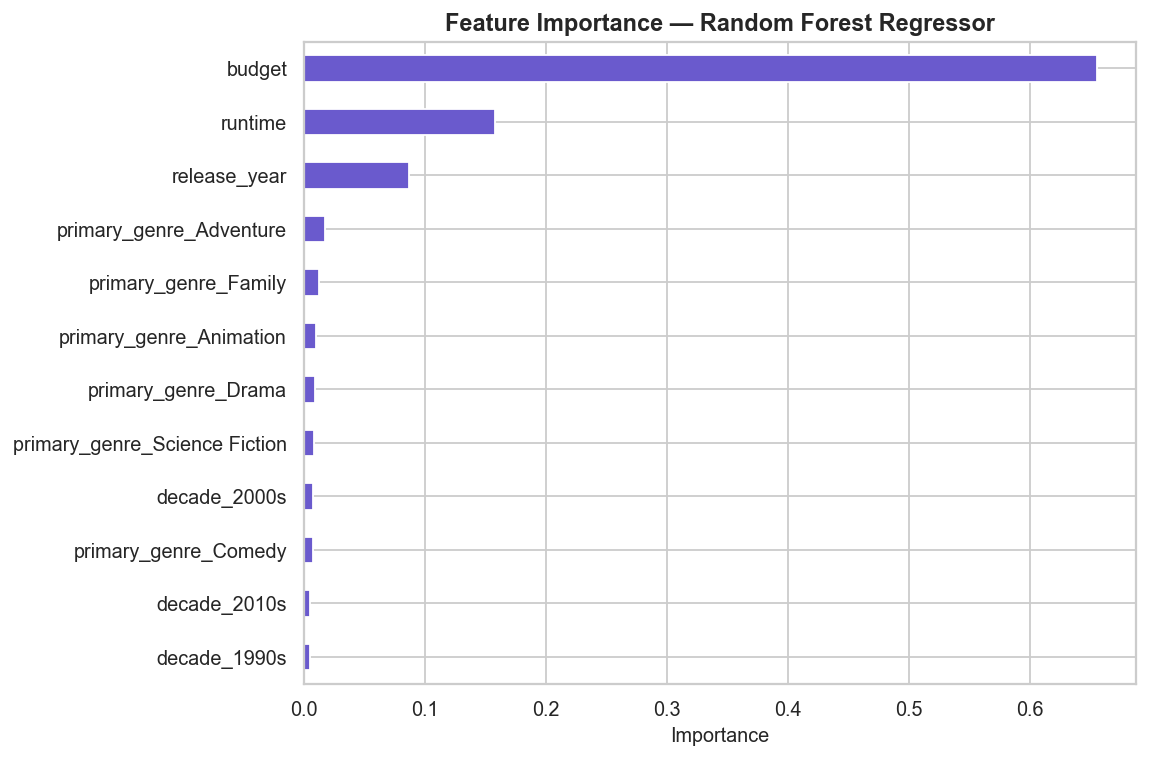

In [4]:
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest Regressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation:** `budget` accounts for **63.6%** of feature importance on its own. A distant second is `runtime` (16.1%), then `release_year` (9.5%). All genre and decade variables together remain at ~10%. This confirms the research question from the ML angle: budget is the dominant driver in revenue prediction. The unexplained ~46% of variance points to factors absent from the dataset (marketing spend, cast, release timing).

## Actual vs Predicted — Presentation Plot (Random Forest)

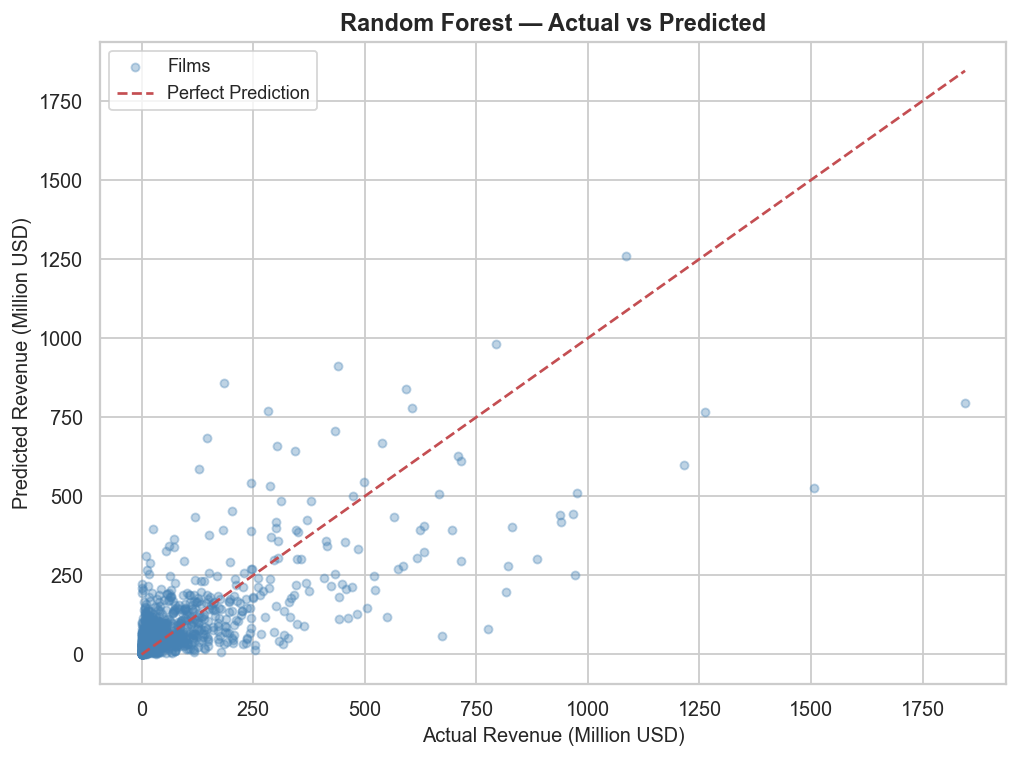

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test / 1e6, y_pred_rf / 1e6, alpha=0.35, s=20, color='steelblue', label='Films')
lim = max(y_test.max(), y_pred_rf.max()) / 1e6
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Revenue (Million USD)', fontsize=11)
ax.set_ylabel('Predicted Revenue (Million USD)', fontsize=11)
ax.set_title('Random Forest — Actual vs Predicted', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Residual Analysis

Residual = Actual − Predicted. Ideal: randomly distributed with no systematic pattern.

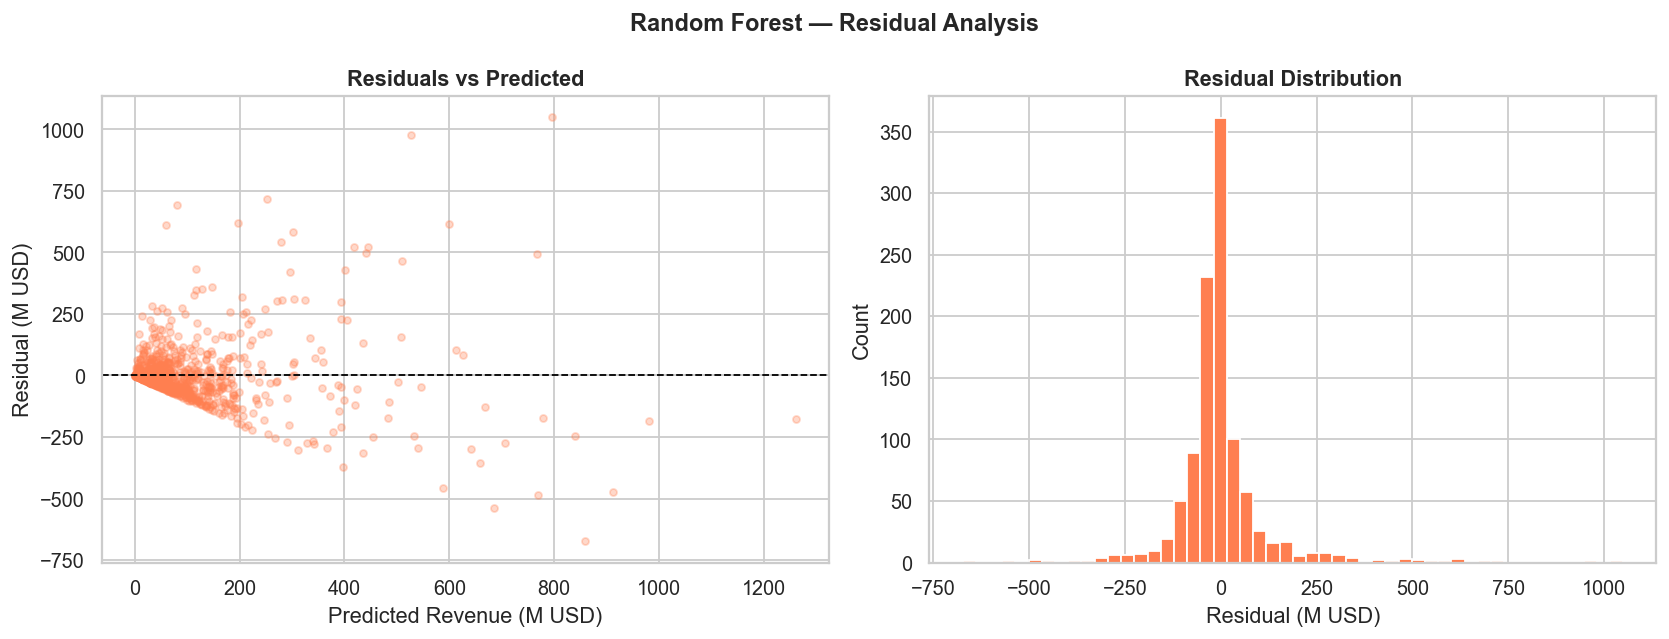

In [6]:
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_rf / 1e6, residuals / 1e6, alpha=0.3, s=15, color='coral')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('Predicted Revenue (M USD)')
axes[0].set_ylabel('Residual (M USD)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

axes[1].hist(residuals / 1e6, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Residual (M USD)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Random Forest — Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Residual mean is +$1.0M (practically zero — the model is unbiased). Standard deviation $122.2M; skew **4.84** — strongly right-skewed. Maximum underprediction is $1,876M: the model dramatically underestimates the largest blockbusters. Maximum overprediction is $571M. High-budget films that underperform (flops) pull predictions upward; blockbusters fall below the line. This asymmetry suggests a log-transformed target variable would reduce the skew and improve performance.

## ML Conclusion

**Best model (test set):** Random Forest — R² = 0.542, MAE $60.8M, RMSE $122.1M  
**Best model (cross-validation):** Linear Regression — CV R² = 0.536 ± 0.047 (vs RF: 0.498 ± 0.078)

**Key finding:** Both models performed similarly on raw scale. CV results show Linear Regression generalizes more stably; Random Forest edges ahead on the single test split but falls behind on cross-validation — a sign of mild overfitting. The largely linear underlying relationship (EDA r = 0.70) explains why RF's added non-linear capacity makes little difference.

**Most important feature:** `budget` — **63.6%** of feature importance. Confirms the EDA correlation finding from the ML angle.

---

### Research Question Answer

> *"Does a bigger budget lead to better ratings and stronger box office results?"*

This question is **fully answered by EDA** — ML is a supplementary layer, not required for the conclusion:

| Dimension | EDA Result | Verdict |
|---|---|---|
| Budget → Revenue | Pearson r = **0.70** | YES — strong positive relationship |
| Budget → IMDb Rating | Pearson r = **-0.057** | NO — budget does not buy quality |
| Budget → Tomatometer | Pearson r = **-0.176** | NO — critics rate big-budget films slightly lower |
| Budget → Best ROI | Low tier median **180%** vs High 69% | NO — smaller budgets deliver better returns |

ML confirms the revenue relationship from the prediction angle (R² = 0.54, budget = 63.6% importance), but the core answer was established in EDA.

---

### Model Performance Context

**Why is RMSE $122M so large?**

| Metric | Value | Context |
|---|---|---|
| RMSE | $122M | Larger than mean revenue ($90M) |
| MAE | $60.8M | 2× the median revenue ($30M) |
| MAPE (raw) | ~123,000% | Driven by Q1 films: predicted ~$23M, actual ~$2M |

The wide error margin exists because revenue is right-skewed (skew = 4.47). A log-transformed model (see notebook 06, Phase 8 section) reduces MAPE substantially but R² stays at ~0.50.

**Limitations:**
- Only films with budget > 0 and revenue > 0 were included (potential selection bias toward mainstream productions)
- Marketing spend, cast, and director history are absent from the data
- Extreme blockbuster outliers are hard to predict (max underprediction: $1,876M)
- Bottom 25% of films (median revenue $2M) are systematically over-predicted — model is unreliable below ~$10M revenue

**Future work:**
- Model log(revenue) as primary target to reduce right-skew in residuals *(partially done in notebook 06)*
- Sentiment analysis on film overviews as a story-quality proxy
- Director and cast historical performance scores as features
- Separate models by budget tier (low / mid / blockbuster)

---
## Export — Presentation Figures & CV Results

Saves final ML plots to `Output/figures/` and cross-validation results to `Output/exports/`.

In [7]:
import json

FIGURES = PROJECT_ROOT / 'Output' / 'figures'
EXPORTS = PROJECT_ROOT / 'Output' / 'exports'
FIGURES.mkdir(parents=True, exist_ok=True)
EXPORTS.mkdir(parents=True, exist_ok=True)

# ── Figure: Feature Importance (horizontal) ───────────────────────────────────
_fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(9, 6))
_fi.plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest Regressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES / 'feature_importance_horizontal.png', dpi=150); plt.close(fig)

# ── Figure: Actual vs Predicted (RF) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test / 1e6, y_pred_rf / 1e6, alpha=0.35, s=20, color='steelblue', label='Films')
_lim = max(y_test.max(), y_pred_rf.max()) / 1e6
ax.plot([0, _lim], [0, _lim], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Revenue (Million USD)', fontsize=11)
ax.set_ylabel('Predicted Revenue (Million USD)', fontsize=11)
ax.set_title('Random Forest — Actual vs Predicted', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES / 'actual_vs_predicted_rf.png', dpi=150); plt.close(fig)

# ── Figure: Residual Analysis ─────────────────────────────────────────────────
_residuals = y_test - y_pred_rf
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred_rf / 1e6, _residuals / 1e6, alpha=0.3, s=15, color='coral')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('Predicted Revenue (M USD)'); axes[0].set_ylabel('Residual (M USD)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[1].hist(_residuals / 1e6, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Residual (M USD)'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
plt.suptitle('Random Forest — Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES / 'residual_analysis.png', dpi=150); plt.close(fig)

# ── JSON: update model_results.json with CV scores ───────────────────────────
_results_path = EXPORTS / 'model_results.json'
_data = json.loads(_results_path.read_text(encoding='utf-8')) if _results_path.exists() else {}
_data.setdefault('regression', {})
_data['regression']['linear_regression']['cv_r2_mean'] = round(float(cv_lr.mean()), 4)
_data['regression']['linear_regression']['cv_r2_std']  = round(float(cv_lr.std()), 4)
_data['regression']['random_forest']['cv_r2_mean']     = round(float(cv_rf.mean()), 4)
_data['regression']['random_forest']['cv_r2_std']      = round(float(cv_rf.std()), 4)
_data['regression']['residual_analysis'] = {
    'mean_M':   round(float(_residuals.mean() / 1e6), 2),
    'std_M':    round(float(_residuals.std() / 1e6), 2),
    'skewness': round(float(pd.Series(_residuals).skew()), 3),
    'max_underprediction_M': round(float(_residuals.max() / 1e6), 1),
    'max_overprediction_M':  round(float(_residuals.min() / 1e6), 1),
}
_results_path.write_text(json.dumps(_data, indent=2), encoding='utf-8')

print('Figures saved to Output/figures/')
print('model_results.json updated with CV scores and residual stats')

Figures saved to Output/figures/
model_results.json updated with CV scores and residual stats
